<a href="https://colab.research.google.com/github/KVaishali810/MSA-visualizer/blob/main/biopython_sequence_analyser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install biopython

In [54]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
print("Biopython imported successfully!")
print(f"Biopython version: {__import__('Bio').__version__}")

Biopython imported successfully!
Biopython version: 1.86


In [55]:
from Bio import Entrez, SeqIO


Entrez.email = "kvaishali002004@gmail.com"

# fetch the human BRCA1 mRNA sequence
accession = "NM_007294"

print(f"Fetching sequence: {accession} from NCBI...")

handle = Entrez.efetch(
    db="nucleotide",      # which database to search
    id=accession,         # accession number
    rettype="fasta",      # format to return
    retmode="text"        # text mode
)

record = SeqIO.read(handle, "fasta")
handle.close()

print(f"\nID          : {record.id}")
print(f"Description : {record.description[:80]}...")
print(f"Length      : {len(record.seq)} bases")
print(f"First 60bp  : {record.seq[:60]}")

Fetching sequence: NM_007294 from NCBI...

ID          : NM_007294.4
Description : NM_007294.4 Homo sapiens BRCA1 DNA repair associated (BRCA1), transcript variant...
Length      : 7088 bases
First 60bp  : GCTGAGACTTCCTGGACGGGGGACAGGCTGTGGGGTTTCTCAGATAACTGGGCCCCTGCG


In [56]:
from Bio.SeqUtils import gc_fraction

seq = record.seq

# basic stats
length     = len(seq)
gc_content = gc_fraction(seq) * 100
at_content = 100 - gc_content

# base counts
count_a = seq.count('A')
count_t = seq.count('T')
count_g = seq.count('G')
count_c = seq.count('C')

print("===== Sequence Analysis =====")
print(f"Accession   : {record.id}")
print(f"Length      : {length} bases")
print(f"GC Content  : {gc_content:.2f}%")
print(f"AT Content  : {at_content:.2f}%")
print(f"\nBase Counts:")
print(f"  A : {count_a} ({100*count_a/length:.2f}%)")
print(f"  T : {count_t} ({100*count_t/length:.2f}%)")
print(f"  G : {count_g} ({100*count_g/length:.2f}%)")
print(f"  C : {count_c} ({100*count_c/length:.2f}%)")

===== Sequence Analysis =====
Accession   : NM_007294.4
Length      : 7088 bases
GC Content  : 41.77%
AT Content  : 58.23%

Base Counts:
  A : 2368 (33.41%)
  T : 1759 (24.82%)
  G : 1585 (22.36%)
  C : 1376 (19.41%)


In [57]:
import pandas as pd
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction
import time

Entrez.email = "kvaishali002004@gmail.com"

# list of accessions to analyze
accessions = {
    "NM_007294" : "BRCA1 - breast cancer gene",
    "NM_000546" : "TP53  - tumor suppressor",
    "NM_005228" : "EGFR  - epidermal growth factor"
}

results = []

for accession, description in accessions.items():
    print(f"Fetching {accession} ({description})...")

    handle = Entrez.efetch(
        db="nucleotide",
        id=accession,
        rettype="fasta",
        retmode="text"
    )
    record = SeqIO.read(handle, "fasta")
    handle.close()

    seq    = record.seq
    length = len(seq)
    gc     = gc_fraction(seq) * 100

    results.append({
        "Accession"   : record.id,
        "Gene"        : description,
        "Length"      : length,
        "GC%"         : round(gc, 2),
        "AT%"         : round(100 - gc, 2),
        "A_count"     : seq.count('A'),
        "T_count"     : seq.count('T'),
        "G_count"     : seq.count('G'),
        "C_count"     : seq.count('C')
    })

    time.sleep(0.5)  # be polite to NCBI - don't hammer their server

# create dataframe
df = pd.DataFrame(results)
print("\n===== Multi-Gene Analysis =====")
print(df.to_string(index=False))

# save to CSV
df.to_csv("gene_analysis.csv", index=False)
print("\nSaved to gene_analysis.csv ")

Fetching NM_007294 (BRCA1 - breast cancer gene)...
Fetching NM_000546 (TP53  - tumor suppressor)...
Fetching NM_005228 (EGFR  - epidermal growth factor)...

===== Multi-Gene Analysis =====
  Accession                            Gene  Length   GC%   AT%  A_count  T_count  G_count  C_count
NM_007294.4      BRCA1 - breast cancer gene    7088 41.77 58.23     2368     1759     1585     1376
NM_000546.6        TP53  - tumor suppressor    2512 53.38 46.62      532      639      621      720
NM_005228.5 EGFR  - epidermal growth factor    9905 47.78 52.22     2736     2436     2282     2451

Saved to gene_analysis.csv 


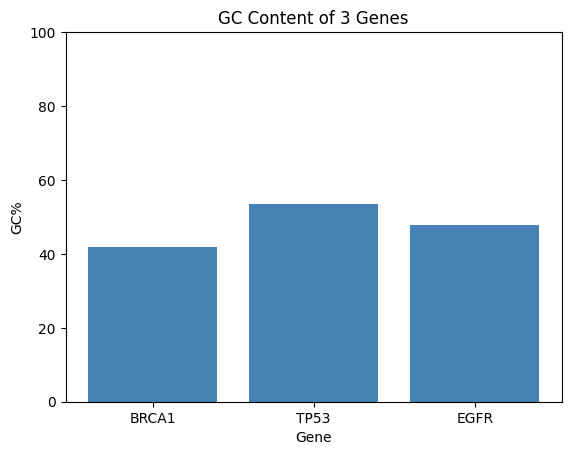

In [58]:
import matplotlib.pyplot as plt

# data
genes = ['BRCA1', 'TP53', 'EGFR']
gc    = [41.77, 53.38, 47.78]

# plot
plt.bar(genes, gc, color='steelblue')
plt.title('GC Content of 3 Genes')
plt.xlabel('Gene')
plt.ylabel('GC%')
plt.ylim(0, 100)
plt.savefig('gene_analysis.png')
plt.show()

In [59]:
# ============================================
#   Multiple Sequence Alignment Visualizer
# ============================================

from Bio import AlignIO
from Bio.Align import MultipleSeqAlignment, PairwiseAligner
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import numpy as np

# --- our sequences (BRCA1 fragment from 5 species) ---
sequences = {
    "Human" :  "ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG",
    "Mouse" :  "ATGCAATCGATCGATCGTAGCTAGCAAGCATCGATCGATCG",
    "Rat"   :  "ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGTTCG",
    "Dog"   :  "ATGCGATCGATCGATCGTAGCAAGCTAGCATCGATCGATCG",
    "Chimp" :  "ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG"
}

# print sequences
print("===== Input Sequences =====")
for species, seq in sequences.items():
    print(f"{species:6} : {seq}")
print(f"\nSequence length : {len(list(sequences.values())[0])} bp")
print(f"Number of species : {len(sequences)}")

===== Input Sequences =====
Human  : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG
Mouse  : ATGCAATCGATCGATCGTAGCTAGCAAGCATCGATCGATCG
Rat    : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGTTCG
Dog    : ATGCGATCGATCGATCGTAGCAAGCTAGCATCGATCGATCG
Chimp  : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG

Sequence length : 41 bp
Number of species : 5


In [60]:
# --- calculate conservation score per position ---
seqs = list(sequences.values())
species = list(sequences.keys())
length = len(seqs[0])

conservation = []

for i in range(length):
    # get all bases at this position
    bases_at_position = [seq[i] for seq in seqs]

    # most common base
    most_common = max(set(bases_at_position),
                      key=bases_at_position.count)

    # conservation score = fraction of sequences with most common base
    score = bases_at_position.count(most_common) / len(seqs)
    conservation.append(score)

# print summary
fully_conserved = sum(1 for s in conservation if s == 1.0)
variable = sum(1 for s in conservation if s < 1.0)

print("===== Conservation Analysis =====")
print(f"Total positions    : {length}")
print(f"Fully conserved    : {fully_conserved}")
print(f"Variable positions : {variable}")
print(f"\nConservation scores (first 10 positions):")
for i in range(10):
    bases = [seq[i] for seq in seqs]
    print(f"  Position {i+1:2d} : {bases} → score {conservation[i]:.2f}")

===== Conservation Analysis =====
Total positions    : 41
Fully conserved    : 37
Variable positions : 4

Conservation scores (first 10 positions):
  Position  1 : ['A', 'A', 'A', 'A', 'A'] → score 1.00
  Position  2 : ['T', 'T', 'T', 'T', 'T'] → score 1.00
  Position  3 : ['G', 'G', 'G', 'G', 'G'] → score 1.00
  Position  4 : ['C', 'C', 'C', 'C', 'C'] → score 1.00
  Position  5 : ['G', 'A', 'G', 'G', 'G'] → score 0.80
  Position  6 : ['A', 'A', 'A', 'A', 'A'] → score 1.00
  Position  7 : ['T', 'T', 'T', 'T', 'T'] → score 1.00
  Position  8 : ['C', 'C', 'C', 'C', 'C'] → score 1.00
  Position  9 : ['G', 'G', 'G', 'G', 'G'] → score 1.00
  Position 10 : ['A', 'A', 'A', 'A', 'A'] → score 1.00


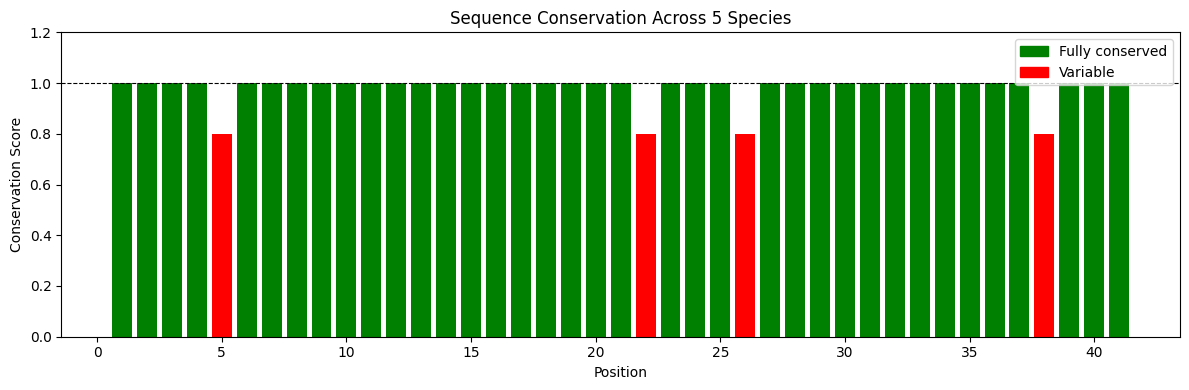

Plot saved 


In [61]:
# --- visualize conservation ---
positions = list(range(1, length + 1))

# assign colors - green for conserved, red for variable
colors = ['green' if s == 1.0 else 'red' for s in conservation]

plt.figure(figsize=(12, 4))
plt.bar(positions, conservation, color=colors)
plt.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Position')
plt.ylabel('Conservation Score')
plt.title('Sequence Conservation Across 5 Species')
plt.ylim(0, 1.2)

# add legend manually
from matplotlib.patches import Patch
legend = [Patch(color='green', label='Fully conserved'),
          Patch(color='red',   label='Variable')]
plt.legend(handles=legend)

plt.tight_layout()
plt.savefig('conservation_plot.png')
plt.show()
print("Plot saved ")

In [62]:
# --- print pretty alignment ---
print("===== Multiple Sequence Alignment =====\n")

# print each species sequence
for species_name, seq in sequences.items():
    print(f"{species_name:6} : {seq}")

# print conservation line below
print("\nConserv:", end=" ")
consensus = ""
for i in range(length):
    bases = [seq[i] for seq in seqs]
    if len(set(bases)) == 1:
        consensus += "|"    # fully conserved
    else:
        consensus += "."    # variable
print(consensus)

# print consensus sequence
print("\nConsens:", end=" ")
for i in range(length):
    bases = [seq[i] for seq in seqs]
    most_common = max(set(bases), key=bases.count)
    print(most_common, end="")
print()

print(f"\n| = conserved   . = variable")
print(f"Conserved : {fully_conserved}/41 ({100*fully_conserved/length:.1f}%)")

===== Multiple Sequence Alignment =====

Human  : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG
Mouse  : ATGCAATCGATCGATCGTAGCTAGCAAGCATCGATCGATCG
Rat    : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGTTCG
Dog    : ATGCGATCGATCGATCGTAGCAAGCTAGCATCGATCGATCG
Chimp  : ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG

Conserv: ||||.||||||||||||||||.|||.|||||||||||.|||

Consens: ATGCGATCGATCGATCGTAGCTAGCTAGCATCGATCGATCG

| = conserved   . = variable
Conserved : 37/41 (90.2%)
